Import thư viện

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string #xử lý chuỗi liên quan tới bảng chữ cái, ký tự đặc biệt
import re #xử lý chuỗi bằng Regular Expression để làm sạch và trích xuất dữ liệu

from sklearn.linear_model import LogisticRegression             # mô hình phân loại logistic
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split            # chia dữ liệu train/test
from sklearn.feature_extraction.text import TfidfVectorizer     # biến text thành vector số (TF-IDF)
from sklearn.metrics import (
    accuracy_score,         # độ chính xác %
    classification_report,  # báo cáo precision, recall, f1-score
    confusion_matrix,       # Ma rận nhầm lẫn
    ConfusionMatrixDisplay  # vẽ trực quan confusion matrix
)

import joblib # tải model


Load data

In [3]:
df = pd.read_csv('email.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.shape

(5572, 2)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [6]:
df.describe() .T

,count,unique,top,freq
Category,5572,2,ham,4825
Message,5572,5157,"Sorry, I'll call later",30


In [7]:
df.columns.tolist()

['Category', 'Message']

In [8]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [9]:
df.nunique()

Category       2
Message     5157
dtype: int64

EDA

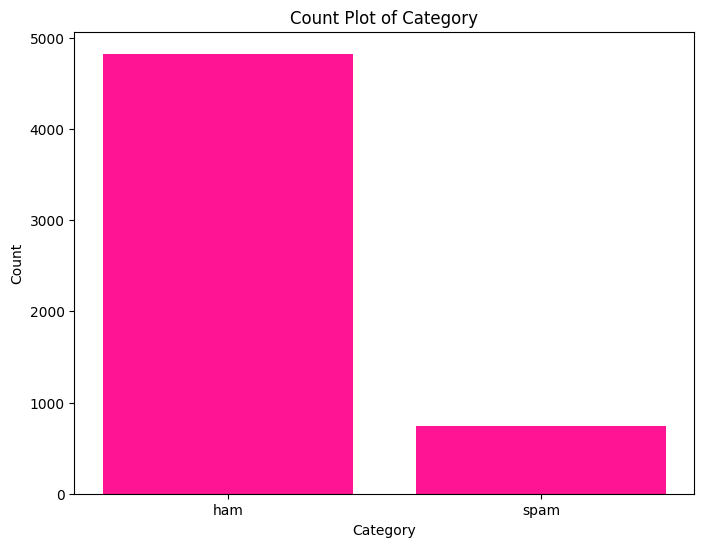

In [10]:
# dùng bar plot để biết tỉ lệ ham hay spam
quality_counts = df['Category'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(quality_counts.index, quality_counts, color='deeppink')
plt.title('Count Plot of Category') # Pân bố dữ liệu
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

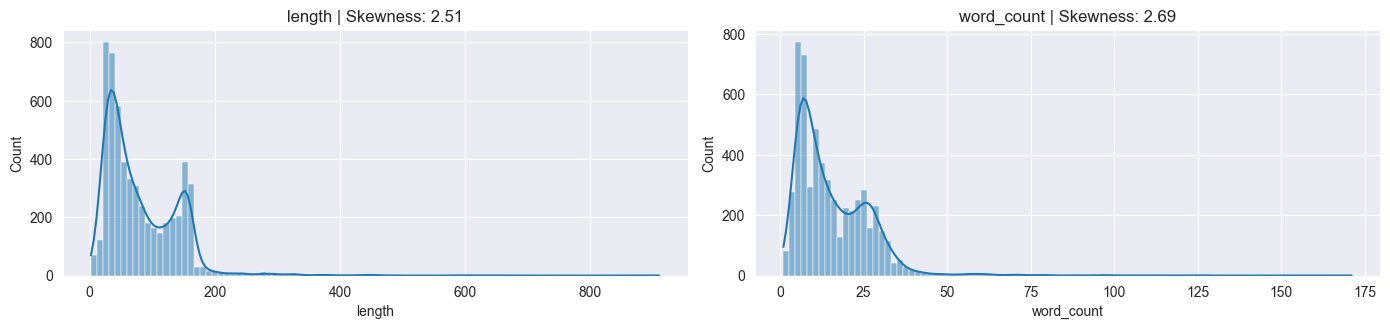

In [11]:
# dùng Kernel density plot (biểu đồ hạt nhân) để hiểu sự phân bố và độ lệch trong cột dữ liệu
"""Ở biểu đồ này, ta thấy skewness = 2.51; 2.69 > 0 là dữ liệu bị lệch về bên phải cho thấy email spam thường kéo dài về phía sau"""
sns.set_style("darkgrid")

# tạo feature số từ text
df['length'] = df['Message'].apply(len) # độ dài tin nhắn
df['word_count'] = df['Message'].apply(lambda x: len(x.split())) # số từ


numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_18796\2012533965.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Category', y='num_punctuation', data=df.sample(1000, random_state=42), palette='viridis', size=3)
d:\Codepython\Practice\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
d:\Codepython\Practice\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


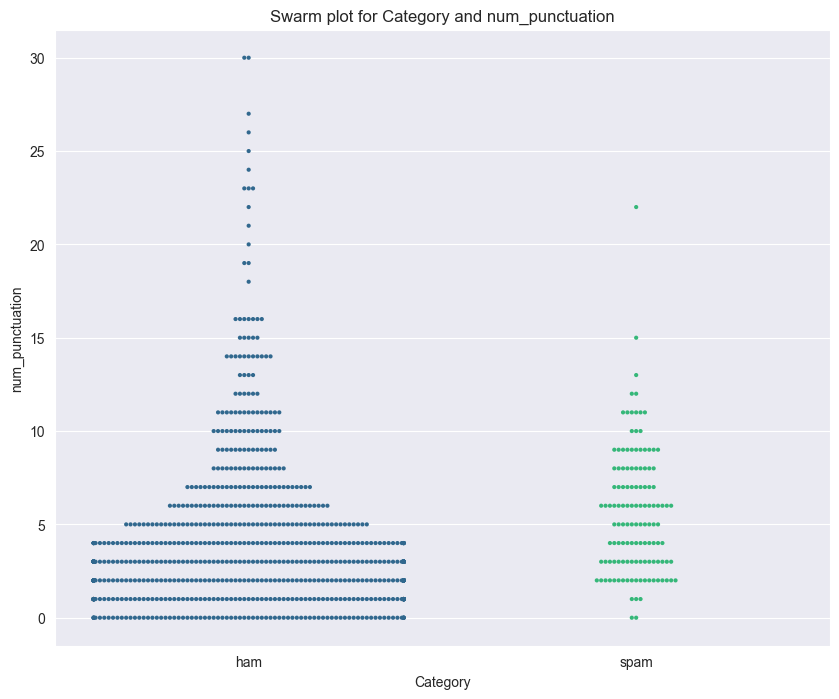

In [12]:
# Dùng swarm plot để hiển thị ngoại lệ trong dữ liệu
df['num_punctuation'] = df['Message'].apply(lambda x: len([char for char in x if char in string.punctuation]))

plt.figure(figsize=(10, 8))

sns.swarmplot(x='Category', y='num_punctuation', data=df.sample(1000, random_state=42), palette='viridis', size=3)

plt.title('Swarm plot for Category and num_punctuation')
plt.xlabel('Category')
plt.ylabel('num_punctuation')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_18796\1812588060.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Category', y='num_caps', data=df, palette={'ham': 'lightskyblue', 'spam': 'lightcoral'}, alpha=0.7)


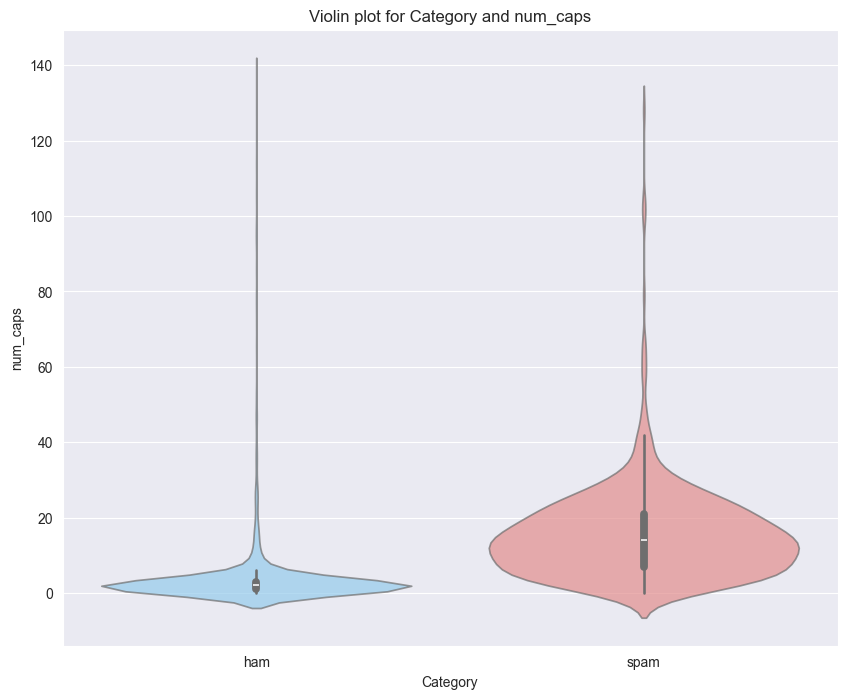

In [13]:
# Violin plot để kiếm tra mối quan hệ giữa category và num_caps
df['Category'] = df['Category'].astype(str)
df['num_caps'] = df['Message'].apply(lambda x: sum(1 for char in x if char.isupper()))

plt.figure(figsize=(10, 8))

sns.violinplot(x='Category', y='num_caps', data=df, palette={'ham': 'lightskyblue', 'spam': 'lightcoral'}, alpha=0.7)

plt.title('Violin plot for Category and num_caps')
plt.xlabel('Category')
plt.ylabel('num_caps')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_18796\1605843859.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='total_hot_words', data=df, palette={'ham': 'skyblue', 'spam': 'salmon'})


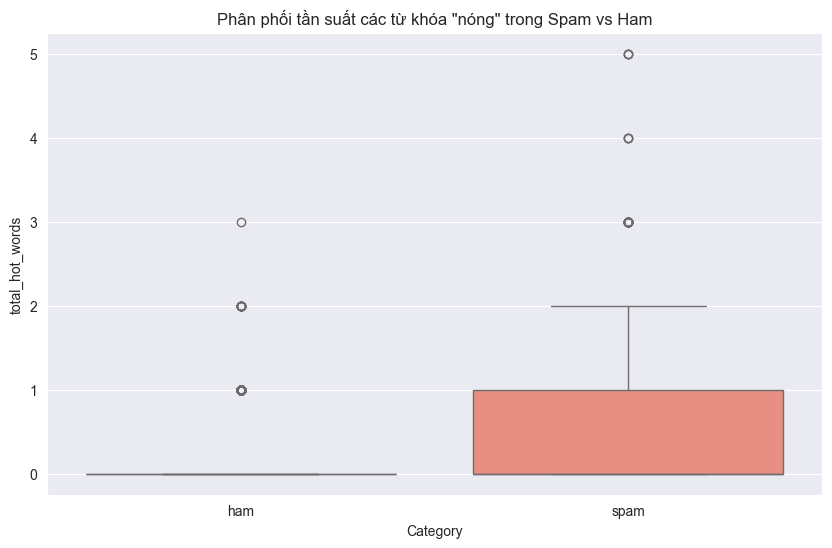

In [ ]:
# Định nghĩa danh sách từ khóa "nóng"
hot_words = ['free', 'win', 'click', 'money', 'prize', 'urgent', 'winner']

# 2. Tạo cột đếm tổng số lần các từ này xuất hiện trong Message
df['total_hot_words'] = df['Message'].apply(lambda x: sum(x.lower().count(word) for word in hot_words))

# 3. Vẽ Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='total_hot_words', data=df, palette={'ham': 'skyblue', 'spam': 'salmon'})
plt.title('Phân phối tần suất các từ khóa "nóng" trong Spam vs Ham')
plt.show()

Tiền xử lý dữ liệu:

- Làm sạch và chuẩn hoá dữ liệu

In [15]:
# Tiền xử lý văn bản

def clean_text(text):
    text = text.lower()                                 # đổi "Free Money" thành "free money"
    text = re.sub(f"[{string.punctuation}]", "", text)  # xoá dấu câu: "Hello^^* Free?? Money." thành "Hello Free Money"
    text = re.sub(r"\d+", "", text)                     # xoá số: "win 1000 dollars now" thành "win dollars now"
    return text

df['Message'] = df['Message'].apply(clean_text)

- Mã hoá nhãn

In [16]:
df = df[df["Category"].isin(['ham', 'spam'])] # chỉ lấy các mẫu spam và ham

X = df["Message"]
y = df["Category"]

print("Kiểm tra phân bố nhãn: ")
print(y.value_counts())

print("\nKiểm tra phân bố nhãn theo tỷ lệ: ")
print(y.value_counts()/len(y))

y = y.map({
    'ham': 0,
    'spam': 1
}) # chuyển đổi nhãn thành số

Kiểm tra phân bố nhãn: 
Category
ham     4825
spam     747
Name: count, dtype: int64

Kiểm tra phân bố nhãn theo tỷ lệ: 
Category
ham     0.865937
spam    0.134063
Name: count, dtype: float64


Xử lý dữ liệu:

- Chia tập train/test

In [17]:
# Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

print("Đã chia train/test với tỉ lệ 80/20")

Đã chia train/test với tỉ lệ 80/20


- TF-IDF Vectorizer

In [18]:
# Chuyển đổi văn bản thành vector số
vectorizer = TfidfVectorizer()

# huấn luyện vectorizer với dữ liệu huấn luyện
vectorizer.fit(X_train)

# chuyển đổi dữ liệu huấn luyện thành vector số
X_train_tfidf = vectorizer.transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)


Huấn luyện mô hình:

In [19]:
# sử dụng mô hình logistic regression
model = LogisticRegression(
    class_weight = "balanced"
)

model.fit(X_train_tfidf, y_train)

print("Đã huấn luyện mô hình")

Đã huấn luyện mô hình


Đánh giá mô hình:

Logistic Regression (train 80% / test 20%)
Accuracy:  0.9739910313901345

Confusion Matrix: 


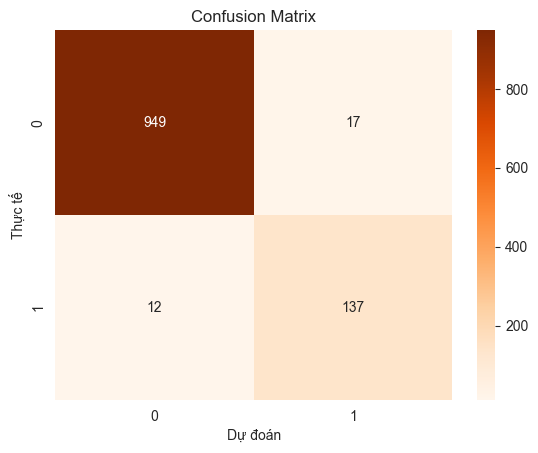


Classification Report: 
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       966
           1       0.89      0.92      0.90       149

    accuracy                           0.97      1115
   macro avg       0.94      0.95      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [20]:
# Dự đoán nhãn trên tập test
y_pred = model.predict(X_test_tfidf)

# tính độ chính xác
acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression (train 80% / test 20%)")
print("Accuracy: ", acc)

# vẽ ma trận nhầm lẫn
print("\nConfusion Matrix: ")
cm = confusion_matrix(y_test, y_pred)
plt.Figure(figsize=(4,4))
sns.heatmap(
    cm,             
    annot = True,   # in giá trị trong mỗi ô
    fmt = "d",      # định dãng số nguyên
    cmap = "Oranges"  # màu cam
)
plt.title("Confusion Matrix")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show()

# báo cáo chi tiết các chỉ số: percision, recall, f1-score
print("\nClassification Report: ")
print(classification_report(y_test, y_pred))